# Softmax Regression (Multi-class Logistic)
Train and tune a multinomial logistic regression model (Softmax Regression) for the 3-class diabetes target.

In [69]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
 )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Strict GPU-only mode: this notebook should not run on CPU fallback.
USE_GPU = True
GPU_BACKEND = "cpu"
GPU_STATUS_MESSAGE = "GPU mode initialization pending."

try:
    # Actually, a workaround for pandas/cudf pyarrow conflict: 
    # Unregister what cudf/pandas are fighting over
    import pyarrow as pa
    try:
        pa.unregister_extension_type("pandas.period")
        pa.unregister_extension_type("pandas.interval")
    except Exception:
        pass

    import cupy as cp
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    from cuml.preprocessing import StandardScaler as cuStandardScaler

    device_count = cp.cuda.runtime.getDeviceCount()
    if device_count <= 0:
        raise RuntimeError("No CUDA GPU device detected.")

    GPU_BACKEND = "gpu"
    dev_id = cp.cuda.runtime.getDevice()
    dev_name = cp.cuda.runtime.getDeviceProperties(dev_id)["name"].decode("utf-8")
    GPU_STATUS_MESSAGE = f"GPU mode enabled on CUDA device {dev_id}: {dev_name}"
except Exception as gpu_import_error:
    raise RuntimeError(
        "GPU-only mode is enabled, but CUDA/cuML initialization failed. "
        "Fix the environment (driver/CUDA/cuML/pandas compatibility) and rerun. "
        f"Original error: {gpu_import_error}"
    ) from gpu_import_error

print(GPU_STATUS_MESSAGE)

GPU mode enabled on CUDA device 0: NVIDIA GeForce RTX 3070 Laptop GPU


In [70]:
import re
from pathlib import Path
import pandas as pd

dataset_dir = Path("datasets")
csv_paths = sorted(dataset_dir.rglob("*.csv"))

target_col = "Diabetes_012"
train_datasets = {}
val_datasets = {}
test_datasets = {}

for path in csv_paths:
    df_candidate = pd.read_csv(path)
    if target_col not in df_candidate.columns:
        print(f"Skipping {path}: missing target column '{target_col}'")
        continue

    # Determine k-value to match features between train, val, and test splits
    k_match = re.search(r'(k\d+)', path.name)
    k_key = k_match.group(1) if k_match else "k21" # BaseDataset has 21 features (22 cols)
    
    # Determine the context/source of the dataset (oversampling vs undersampling)
    if "oversampling" in path.parts:
        source_mod = "oversampling"
    elif "undersampling" in path.parts:
        source_mod = "undersampling"
    else:
        source_mod = "base"

    dataset_key = f"{source_mod}_{k_key}"

    name_lower = path.name.lower()
    if "val" in name_lower:
        val_datasets[dataset_key] = df_candidate
    elif "test" in name_lower:
        test_datasets[dataset_key] = df_candidate
    else:
        train_datasets[path.as_posix()] = df_candidate

print(f"Loaded {len(train_datasets)} training dataset(s):")
for name, data in train_datasets.items():
    print(f"- {name}: {data.shape}")

print(f"\nLoaded validation sets for: {list(val_datasets.keys())}")
print(f"Loaded testing sets for: {list(test_datasets.keys())}")

active_dataset_name = "datasets/BaseDataset.csv"
if active_dataset_name not in train_datasets:
    active_dataset_name = next(iter(train_datasets))

df_active = train_datasets[active_dataset_name].copy()
X = df_active.drop(columns=[target_col])
y = df_active[target_col].astype(int)

print(f"\nActive training dataset: {active_dataset_name}")
print(f"Feature matrix shape: {X.shape}")
print("Class distribution:")
print(y.value_counts(normalize=True).sort_index().rename("proportion"))

Loaded 7 training dataset(s):
- datasets/BaseDataset.csv: (253680, 22)
- datasets/oversampling/Smote_k12.csv: (399114, 13)
- datasets/oversampling/Smote_k21.csv: (399114, 22)
- datasets/oversampling/Smote_k9.csv: (399114, 10)
- datasets/undersampling/undersampling_train_k12.csv: (9720, 13)
- datasets/undersampling/undersampling_train_k21.csv: (9720, 22)
- datasets/undersampling/undersampling_train_k9.csv: (9720, 10)

Loaded validation sets for: ['oversampling_k12', 'oversampling_k21', 'oversampling_k9', 'undersampling_k12', 'undersampling_k21', 'undersampling_k9']
Loaded testing sets for: ['oversampling_k12', 'oversampling_k21', 'oversampling_k9', 'undersampling_k12', 'undersampling_k21', 'undersampling_k9']

Active training dataset: datasets/BaseDataset.csv
Feature matrix shape: (253680, 21)
Class distribution:
Diabetes_012
0    0.842412
1    0.018255
2    0.139333
Name: proportion, dtype: float64


In [71]:
split_store = {}

for name, data in train_datasets.items():
    Xi_train = data.drop(columns=[target_col])
    yi_train = data[target_col].astype(int)

    # Infer k_key and folder from file name
    k_match = re.search(r'(k\d+)', name)
    k_key = k_match.group(1) if k_match else "k21"
    
    if "oversampling" in name:
        source_mod = "oversampling"
    elif "undersampling" in name:
        source_mod = "undersampling"
    else:
        source_mod = "base"
        
    dataset_key = f"{source_mod}_{k_key}"

    # Base dataset doesn't have custom val/test files, so we fall back to the oversampling ones 
    # (which are inherently just the standard train_test_split from BaseDataset anyway)
    val_key = dataset_key if dataset_key in val_datasets else f"oversampling_{k_key}"
    test_key = dataset_key if dataset_key in test_datasets else f"oversampling_{k_key}"

    val_data = val_datasets[val_key]
    test_data = test_datasets[test_key]

    Xi_val = val_data.drop(columns=[target_col])
    yi_val = val_data[target_col].astype(int)

    Xi_test = test_data.drop(columns=[target_col])
    yi_test = test_data[target_col].astype(int)

    split_store[name] = {
        "X_train": Xi_train,
        "X_val": Xi_val,
        "X_test": Xi_test,
        "y_train": yi_train,
        "y_val": yi_val,
        "y_test": yi_test,
    }

active_split = split_store[active_dataset_name]
X_train = active_split["X_train"]
X_val = active_split["X_val"]
X_test = active_split["X_test"]
y_train = active_split["y_train"]
y_val = active_split["y_val"]
y_test = active_split["y_test"]

def class_proportions(series):
    return series.value_counts(normalize=True).sort_index().rename("proportion")

total_original = 253680  # Size of original BaseDataset.csv for reference

print(
    f"Active split sizes ({active_dataset_name}):\n"
    f"Train={len(y_train)} "
    f"Validation={len(y_val)} ({len(y_val)/total_original:.2%}), "
    f"Test={len(y_test)} ({len(y_test)/total_original:.2%})"
)

print("\nClass distribution by split (active dataset):")
print("Train:")
print(class_proportions(y_train))
print("\nValidation:")
print(class_proportions(y_val))
print("\nTest:")
print(class_proportions(y_test))

Active split sizes (datasets/BaseDataset.csv):
Train=253680 Validation=22978 (9.06%), Test=45957 (18.12%)

Class distribution by split (active dataset):
Train:
Diabetes_012
0    0.842412
1    0.018255
2    0.139333
Name: proportion, dtype: float64

Validation:
Diabetes_012
0    0.827095
1    0.020150
2    0.152755
Name: proportion, dtype: float64

Test:
Diabetes_012
0    0.827121
1    0.020149
2    0.152730
Name: proportion, dtype: float64


In [72]:
# Train one Softmax model per dataset and select C by validation macro F1.
c_values = [0.01, 0.1, 1.0, 3.0, 10.0, 30.0]
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def _to_numpy(y_like):
    return cp.asnumpy(y_like)

def fit_predict_for_c(X_train_df, y_train_sr, X_eval_df, c):
    if not (USE_GPU and GPU_BACKEND == "gpu"):
        raise RuntimeError("GPU-only mode requires USE_GPU=True and GPU_BACKEND='gpu'.")

    X_train_gpu = cp.asarray(X_train_df.to_numpy(dtype=np.float32))
    y_train_gpu = cp.asarray(y_train_sr.to_numpy(dtype=np.int32))
    X_eval_gpu = cp.asarray(X_eval_df.to_numpy(dtype=np.float32))

    scaler = cuStandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_gpu)
    X_eval_scaled = scaler.transform(X_eval_gpu)

    clf = cuLogisticRegression(
        penalty="l2",
        tol=1e-8,
        C=c,
        max_iter=2000,
        fit_intercept=True,
    )
    clf.fit(X_train_scaled, y_train_gpu)
    y_eval_pred = clf.predict(X_eval_scaled)

    model_bundle = {
        "backend": "gpu",
        "scaler": scaler,
        "model": clf,
    }
    return model_bundle, _to_numpy(y_eval_pred)

def predict_bundle(model_bundle, X_df):
    X_gpu = cp.asarray(X_df.to_numpy(dtype=np.float32))
    X_scaled = model_bundle["scaler"].transform(X_gpu)
    y_pred = model_bundle["model"].predict(X_scaled)
    return _to_numpy(y_pred)

trained_models = {}
validation_tables = {}

for name, split in split_store.items():
    Xi_train = split["X_train"]
    yi_train = split["y_train"]
    Xi_val = split["X_val"]
    yi_val = split["y_val"]

    val_scores = []
    for c in c_values:
        _, yi_val_pred = fit_predict_for_c(Xi_train, yi_train, Xi_val, c)
        val_f1_macro = f1_score(yi_val, yi_val_pred, average="macro")
        val_recall_macro = recall_score(yi_val, yi_val_pred, average="macro")
        val_recall_weighted = recall_score(yi_val, yi_val_pred, average="weighted")
        val_acc = accuracy_score(yi_val, yi_val_pred)
        val_scores.append(
            {
                "C": c,
                "val_f1_macro": val_f1_macro,
                "val_recall_macro": val_recall_macro,
                "val_recall_weighted": val_recall_weighted,
                "val_accuracy": val_acc,
            }
        )

    val_results = pd.DataFrame(val_scores).sort_values(
        ["val_f1_macro", "val_recall_macro", "val_accuracy"],
        ascending=False,
    ).reset_index(drop=True)
    best_c = float(val_results.loc[0, "C"])

    # Refit best model just on train (to not dilute the resampled train distribution)
    best_model_bundle, _ = fit_predict_for_c(Xi_train, yi_train, Xi_val, best_c)

    trained_models[name] = {
        "bundle": best_model_bundle,
        "best_c": best_c,
        "backend": best_model_bundle["backend"],
    }
    validation_tables[name] = val_results

print(f"Execution backend: {GPU_BACKEND} (USE_GPU={USE_GPU})")
print(f"Trained {len(trained_models)} model(s).")
pd.DataFrame(
    [{"dataset": n, "best_C": v["best_c"], "backend": v["backend"]} for n, v in trained_models.items()]
).sort_values("dataset").reset_index(drop=True)

[2026-03-18 09:11:05.478] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:05.670] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:05.889] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:06.459] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:06.629] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:06.848] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:07.038] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:07.207] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[2026-03-18 09:11:07.388] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[

,dataset,best_C,backend
0,datasets/BaseDataset.csv,10.00,gpu
1,datasets/oversampling/Smote_k12.csv,0.01,gpu
2,datasets/oversampling/Smote_k21.csv,0.01,gpu
3,datasets/oversampling/Smote_k9.csv,0.01,gpu
4,datasets/undersampling/undersampling_train_k12...,10.00,gpu
5,datasets/undersampling/undersampling_train_k21...,0.01,gpu
6,datasets/undersampling/undersampling_train_k9.csv,3.00,gpu


In [73]:
for name, payload in trained_models.items():
    model_bundle = payload["bundle"]
    backend = payload["backend"]
    
    # Extract the actual Logistic Regression model object
    if backend == "cpu":
        # In the CPU bundle, the model is inside a scikit-learn Pipeline
        clf = model_bundle["model"].named_steps["softmax"]
        iterations = clf.n_iter_[0]
    else:
        # In the GPU bundle, the model is the cuML LogisticRegression object directly
        clf = model_bundle["model"]
        # Note: Depending on your cuML version, n_iter_ might not be exposed. 
        # If it throws an error, you can wrap it in a try-except block.
        try:
            iterations = clf.n_iter_
        except AttributeError:
            iterations = "Hidden by cuML"
            
    print(f"Dataset: {name}")
    print(f"-> Backend: {backend.upper()}")
    print(f"-> Iterations used: {iterations} / 2000\n")

Dataset: datasets/BaseDataset.csv
-> Backend: GPU
-> Iterations used: [36] / 2000

Dataset: datasets/oversampling/Smote_k12.csv
-> Backend: GPU
-> Iterations used: [27] / 2000

Dataset: datasets/oversampling/Smote_k21.csv
-> Backend: GPU
-> Iterations used: [24] / 2000

Dataset: datasets/oversampling/Smote_k9.csv
-> Backend: GPU
-> Iterations used: [22] / 2000

Dataset: datasets/undersampling/undersampling_train_k12.csv
-> Backend: GPU
-> Iterations used: [21] / 2000

Dataset: datasets/undersampling/undersampling_train_k21.csv
-> Backend: GPU
-> Iterations used: [26] / 2000

Dataset: datasets/undersampling/undersampling_train_k9.csv
-> Backend: GPU
-> Iterations used: [27] / 2000



In [74]:
# Validation leaderboard by dataset (top C per dataset by macro F1).
best_val_rows = []
for name, table in validation_tables.items():
    row0 = table.iloc[0].to_dict()
    best_val_rows.append(
        {
            "dataset": name,
            "best_C": row0["C"],
            "best_val_f1_macro": row0["val_f1_macro"],
            "best_val_recall_macro": row0["val_recall_macro"],
            "best_val_recall_weighted": row0["val_recall_weighted"],
            "best_val_accuracy": row0["val_accuracy"],
        }
    )

val_leaderboard = pd.DataFrame(best_val_rows).sort_values("best_val_f1_macro", ascending=False).reset_index(drop=True)
val_leaderboard

,dataset,best_C,best_val_f1_macro,best_val_recall_macro,best_val_recall_weighted,best_val_accuracy
0,datasets/undersampling/undersampling_train_k21...,0.01,0.424901,0.515086,0.625903,0.625903
1,datasets/undersampling/undersampling_train_k9.csv,3.00,0.423942,0.509030,0.627165,0.627165
2,datasets/oversampling/Smote_k9.csv,0.01,0.423711,0.506477,0.629559,0.629559
3,datasets/undersampling/undersampling_train_k12...,10.00,0.423168,0.509084,0.626860,0.626860
4,datasets/oversampling/Smote_k21.csv,0.01,0.422900,0.510458,0.624684,0.624684
5,datasets/oversampling/Smote_k12.csv,0.01,0.422719,0.506669,0.628471,0.628471
6,datasets/BaseDataset.csv,10.00,0.388964,0.382184,0.831883,0.831883


In [75]:
test_metrics_rows = []
reports_by_dataset = {}
conf_matrices = {}

for name, payload in trained_models.items():
    model_bundle = payload["bundle"]
    Xi_test = split_store[name]["X_test"]
    yi_test = split_store[name]["y_test"]

    yi_pred = predict_bundle(model_bundle, Xi_test)
    cm = confusion_matrix(yi_test, yi_pred, labels=[0, 1, 2])

    metrics_row = {
        "dataset": name,
        "backend": payload["backend"],
        "best_C": payload["best_c"],
        "test_accuracy": accuracy_score(yi_test, yi_pred),
        "test_recall_macro": recall_score(yi_test, yi_pred, average="macro"),
        "test_recall_weighted": recall_score(yi_test, yi_pred, average="weighted"),
        "test_f1_micro": f1_score(yi_test, yi_pred, average="micro"),
        "test_f1_macro": f1_score(yi_test, yi_pred, average="macro"),
        "test_f1_weighted": f1_score(yi_test, yi_pred, average="weighted"),
    }
    test_metrics_rows.append(metrics_row)
    reports_by_dataset[name] = classification_report(yi_test, yi_pred, digits=4)
    conf_matrices[name] = cm

test_metrics = pd.DataFrame(test_metrics_rows).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
test_metrics

/home/ali/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ali/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ali/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,dataset,backend,best_C,test_accuracy,test_recall_macro,test_recall_weighted,test_f1_micro,test_f1_macro,test_f1_weighted
0,datasets/oversampling/Smote_k9.csv,gpu,0.01,0.630633,0.510483,0.630633,0.630633,0.424164,0.703156
1,datasets/undersampling/undersampling_train_k9.csv,gpu,3.00,0.628022,0.510808,0.628022,0.628022,0.423739,0.701904
2,datasets/undersampling/undersampling_train_k12...,gpu,10.00,0.626325,0.507914,0.626325,0.626325,0.422190,0.700986
3,datasets/oversampling/Smote_k12.csv,gpu,0.01,0.628870,0.505213,0.628870,0.628870,0.422111,0.701823
4,datasets/undersampling/undersampling_train_k21...,gpu,0.01,0.624366,0.511308,0.624366,0.624366,0.421937,0.699614
5,datasets/oversampling/Smote_k21.csv,gpu,0.01,0.624976,0.510879,0.624976,0.624976,0.421735,0.699790
6,datasets/BaseDataset.csv,gpu,10.00,0.833540,0.387032,0.833540,0.833540,0.395527,0.793064



datasets/BaseDataset.csv
              precision    recall  f1-score   support

           0     0.8498    0.9730    0.9072     38012
           1     0.0000    0.0000    0.0000       926
           2     0.5428    0.1881    0.2793      7019

    accuracy                         0.8335     45957
   macro avg     0.4642    0.3870    0.3955     45957
weighted avg     0.7858    0.8335    0.7931     45957


datasets/oversampling/Smote_k12.csv
              precision    recall  f1-score   support

           0     0.9405    0.6447    0.7650     38012
           1     0.0313    0.2819    0.0564       926
           2     0.3575    0.5891    0.4450      7019

    accuracy                         0.6289     45957
   macro avg     0.4431    0.5052    0.4221     45957
weighted avg     0.8331    0.6289    0.7018     45957


datasets/oversampling/Smote_k21.csv
              precision    recall  f1-score   support

           0     0.9425    0.6408    0.7629     38012
           1     0.0331    0.

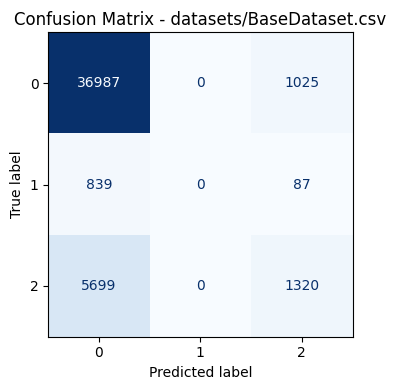

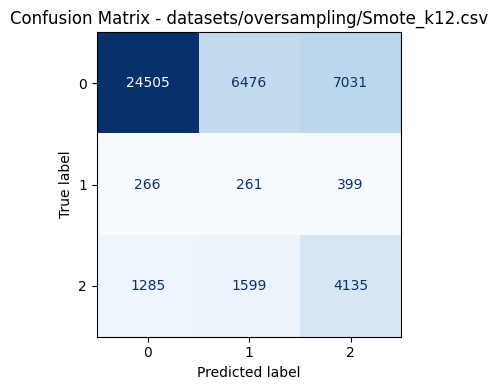

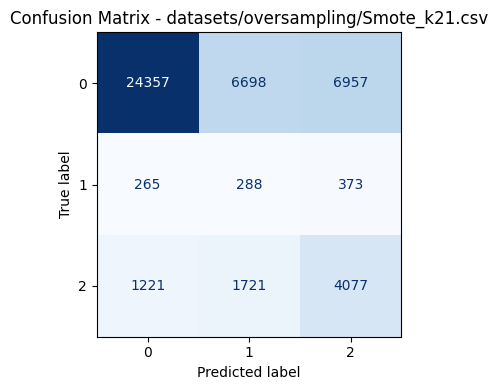

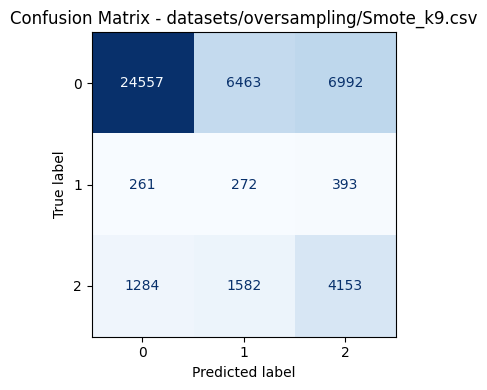

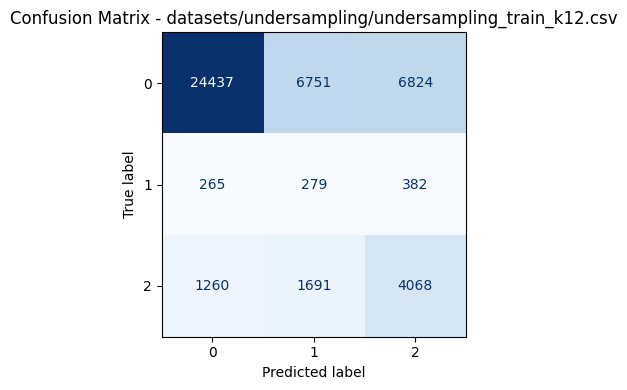

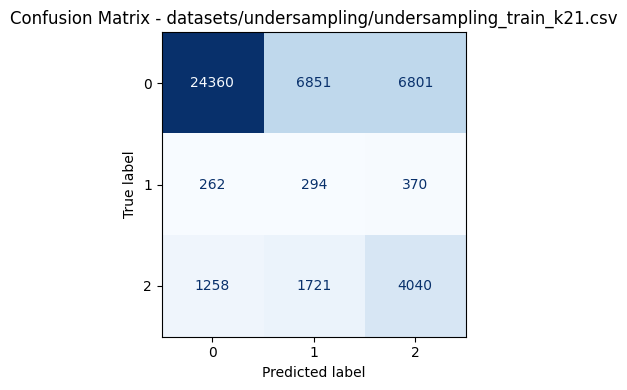

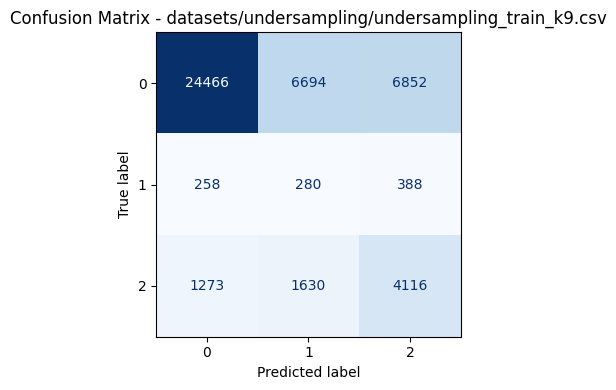

In [76]:
# Show classification reports.
for name in sorted(reports_by_dataset):
    print(f"\n{name}")
    print(reports_by_dataset[name])

# Plot a confusion matrix for each trained model.
for name in sorted(conf_matrices):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrices[name], display_labels=[0, 1, 2])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

## Metric Justification: Why Macro-F1 is Superior

Because the diabetes dataset suffers from severe class imbalance (the 'Prediabetes' class is drastically underrepresented), **Macro-F1** is the most meaningful and reliable metric for model selection.

- **Why Macro-F1?** It calculates the F1-score for each class independently and then takes the unweighted average. This forces the model to treat the tiny "Prediabetes" class as equally important to the massive "No Diabetes" class. If the model fails to detect the minority classes, the Macro-F1 score will plummet, making it the best indicator of true predictive power across all categories.
- **Why not Accuracy or Micro-F1?** In this dataset, a model can achieve over 83% Accuracy (and Micro-F1) by simply predicting "No Diabetes" for every single patient. These metrics mask the model's complete failure to identify sick patients.
- **Why not Weighted-F1?** Weighted-F1 calculates metrics based on the number of true instances for each label. Because the majority of patients are healthy, the healthy class will dominate the calculation, once again hiding the model's poor performance on the minority classes.